# Model 3: BiLSTM + GloVe-Twitter
A bidirectional LSTM (Hochreiter & Schmidhuber, 1997; Schuster & Paliwal, 1997) reads each tweet left-to-right and right-to-left, so every token's representation depends on its context on both sides (e.g. "not safe" vs "safe"). GloVe-Twitter vectors (Pennington et al., 2014), trained on 2B tweets, give meaning to the long tail of rare words found in the EDA (68% of words appear at most twice).

Tuning uses the **validation** split (selection metric: macro-F1, RMSE reported alongside). The final model is evaluated **once** on **test**. Every run is appended to `reports/experiment_log.csv`.

**Seeds.** A first single-seed run of this notebook showed validation macro-F1 moving by ±0.03 between neighbouring epochs and by ±0.018 between seeds of the *same* config, which is as large as most differences between configs. So every config below is trained with **3 seeds** and configs are compared on the **mean** (± std). A config that an earlier experiment already trained is reused, not retrained.

| Exp | Question | Varied | Fixed |
|---|---|---|---|
| L1 | Does pretrained knowledge help? | random / GloVe frozen / GloVe fine-tuned | BiLSTM 128, max-pool, weighted CE |
| L2 | Do direction and pooling matter? | LSTM vs BiLSTM; last / max / attention pooling | best L1 |
| L3 | Does class weighting help the negative class? | unweighted vs weighted CE | best L2 |
| L4 | Capacity and regularisation | hidden {64, 128, 256} x dropout {0.3, 0.5} | best L3, lr 1e-3 |
| L5 | Embedding dimension | GloVe 50 / 100 / 200 | best L4 |

All runs: AdamW (lr 1e-3), batch 64, gradient clipping 1.0, early stopping on validation macro-F1 (patience 5, max 20 epochs, best epoch restored).

**Runtime:** about 2-2.5 h on a laptop CPU, about 15 min on a Colab T4 GPU (Runtime -> Change runtime type -> T4 GPU). The first run also downloads GloVe-Twitter (1.5 GB) once.

In [ ]:
import os, sys

if "google.colab" in sys.modules:
    %pip install -q emoji tokenizers
    from google.colab import drive
    drive.mount("/content/drive")
    BASE = "/content/drive/MyDrive/formative2-vaccine-sentiment"
    GLOVE_DIR = "/content/glove"               
else:
    BASE = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
    GLOVE_DIR = os.path.join(BASE, "data/embeddings/raw")

for d in ["data/processed", "data/embeddings", "reports/figures", "reports/predictions"]:
    os.makedirs(os.path.join(BASE, d), exist_ok=True)
os.chdir(BASE)
sys.path.insert(0, BASE)
print("Working directory:", os.getcwd())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 610.9/610.9 kB 12.9 MB/s eta 0:00:00
Mounted at /content/drive
Working directory: /content/drive/MyDrive/formative2-vaccine-sentiment


## Data and tokenisation
The vocabulary is built on the training split only (words seen at least twice). `!` and `?` are split off as their own tokens: the shared `clean_text` keeps them attached, which would turn "kids", "kids?" and "kids!" into three unrelated words.

In [ ]:
import itertools
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt, seaborn as sns
from IPython.display import display
from src.preprocessing import load_splits
from src.evaluation import evaluate, save_predictions, plot_history
from src.nn_utils import (DEVICE, Vocab, tokenize, make_datasets, make_loaders, class_weights,
                          load_glove_subset, embedding_matrix, glove_coverage, fit, predict, slice_report)
from src.models import BiLSTMClassifier
from src.experiments import Experiments, plot_sweep, history_table

sns.set_theme(style="whitegrid")
FIG, AUTHOR, MODEL = "reports/figures/", "P2", "bilstm_glove"
print("Device:", DEVICE, "| torch threads:", torch.get_num_threads())

train, val, test = load_splits()
vocab = Vocab(train["clean_text"], min_freq=2)
datasets = make_datasets(train, val, test, vocab)
CW = class_weights(train)

lens = train["clean_text"].map(lambda t: len(tokenize(t)))
print(f"Vocab (min_freq=2): {len(vocab)} | tokens/tweet: 95th pct {lens.quantile(.95):.0f}, "
      f"99th {lens.quantile(.99):.0f}, max {lens.max()} -> MAX_LEN 40 truncates nothing")
print("Class weights (neg, neu, pos):", CW.numpy().round(3))

Device: cuda | torch threads: 1
Vocab (min_freq=2): 5100 | tokens/tweet: 95th pct 25, 99th 28, max 36 -> MAX_LEN 40 truncates nothing
Class weights (neg, neu, pos): [3.132 0.69  0.812]


## GloVe-Twitter coverage
The first run downloads `glove.twitter.27B.zip` and caches only the vectors this dataset needs in `data/embeddings/` (a few MB), so later runs skip the download.

Two tokenisation fixes raise coverage: splitting off `!`/`?`, and looking words up under GloVe-Twitter's own spellings (it stores "don't" as "dont" and every number as `<number>`). The table compares naive whitespace tokenisation with the one used here.

In [ ]:
GLOVE = {dim: load_glove_subset(dim, train["clean_text"], glove_dir=GLOVE_DIR) for dim in [50, 100, 200]}
EMB = {dim: embedding_matrix(vocab, GLOVE[dim], dim) for dim in GLOVE}

cov = glove_coverage(vocab, GLOVE[100], train["clean_text"])
naive_tokens = [w for t in train["clean_text"] for w in str(t).split()]
naive_counts = pd.Series(naive_tokens).value_counts()
naive_types = naive_counts[naive_counts >= 2].index
display(pd.DataFrame({
    "vocab (min_freq=2)": [len(naive_types), cov["vocab_size"]],
    "vocab covered by GloVe": [np.mean([w in GLOVE[100] for w in naive_types]), cov["vocab_coverage"]],
    "tokens covered by GloVe": [np.mean([w in GLOVE[100] for w in naive_tokens]), cov["token_coverage"]],
}, index=["whitespace split, exact match", "split !/? + GloVe spellings"]).round(3))
print("Most frequent words still without a GloVe vector:", cov["top_missing"])

,vocab (min_freq=2),vocab covered by GloVe,tokens covered by GloVe
"whitespace split, exact match",5276,0.850,0.913
split !/? + GloVe spellings,5098,0.935,0.969


Most frequent words still without a GloVe vector: ['vaccineswork', 'face_with_tears_of_joy', 'cdcwhistleblower', 'immunized', 'face_with_medical_mask', 'immunize', 'vaccinateyourkids', 'flushed_face', 'mixmasterrod', 'measlesoutbreak', 'loudly_crying_face', 'madhatterdc', 'jennifair', '1st', 'unamused_face', 'raising_hands', 'smiling_face_with_smiling_eyes', 'enraged_face', 'dupontcircle', 'sb277', 'vaxxers', 'vaccinesnova', 'clapping_hands', 'meningococcal', '2nd', 'weary_face', 'tdap', 'immunities', "mixmasterrod's", 'thumbs_up']


## Experiment runner
`train_bilstm(cfg, seed)` trains one config. `Experiments` (in `src/experiments.py`) runs every config with 3 seeds, logs every run, caches configs that two experiments share, and carries each experiment's winner forward, saying whether its lead is larger than the seed noise.

In [ ]:
def train_bilstm(cfg, seed, verbose=False):
    train_dl, val_dl, _ = make_loaders(datasets, seed=seed)
    model = BiLSTMClassifier(len(vocab), cfg["dim"], cfg["hidden"], bidirectional=cfg["bidirectional"],
                             pooling=cfg["pooling"], dropout=cfg["dropout"], freeze=cfg["freeze"],
                             embeddings=None if cfg["emb"] == "random" else EMB[cfg["dim"]])
    hist, best = fit(model, train_dl, val_dl, val["label"], epochs=20, patience=5, lr=cfg["lr"],
                     class_weights=CW if cfg["weighted"] else None, verbose=verbose)
    return model, hist, best


ex = Experiments(train_bilstm, MODEL, author=AUTHOR, seeds=(42, 1, 2),
                 defaults=dict(emb="glove", freeze=False, dim=100, hidden=128, bidirectional=True,
                               pooling="max", dropout=0.5, lr=1e-3, weighted=True))

## L1: embeddings

,emb,freeze,val_macro_f1,f1_std,val_rmse,rmse_std,best_epoch,n_params
0,random,False,0.6024,0.0312,0.6540,0.0242,13.3333,746291
1,glove,True,0.6077,0.0181,0.6339,0.0248,11.6667,236291
2,glove,False,0.6428,0.0058,0.6202,0.0116,12.0000,746291


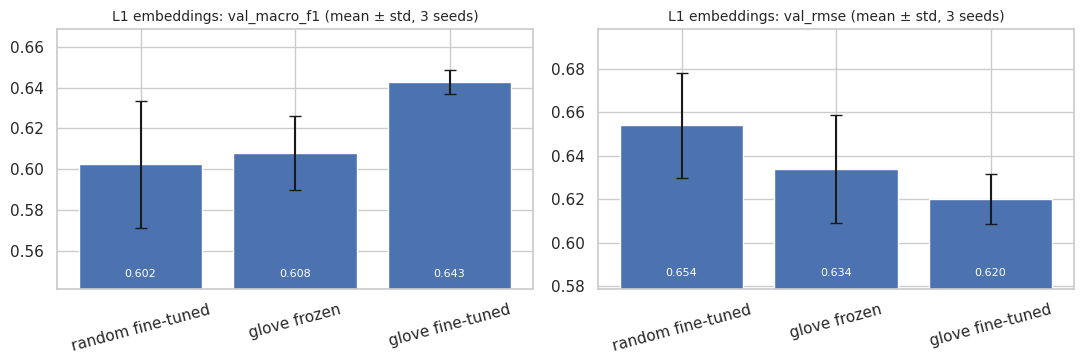

Winner leads the runner-up by 0.0350; seed std 0.0181 -> clear difference
BEST (mean val macro-F1 0.6428): {'emb': 'glove', 'freeze': False, 'dim': 100, 'hidden': 128, 'bidirectional': True, 'pooling': 'max', 'dropout': 0.5, 'lr': 0.001, 'weighted': True}


In [ ]:
l1 = ex.sweep("L1", [dict(emb="random", freeze=False),
                     dict(emb="glove", freeze=True),
                     dict(emb="glove", freeze=False)])
l1["setting"] = l1["emb"] + np.where(l1["freeze"], " frozen", " fine-tuned")
plot_sweep(l1, "setting", "L1 embeddings", FIG + "l1_bilstm_embeddings.png")
ex.update(l1, ["emb", "freeze"])

*Interpretation (L1):* pretrained vectors help, but only when they are fine-tuned. Fine-tuned GloVe reaches 0.643 mean validation macro-F1, against 0.608 for frozen GloVe and 0.602 for random initialisation; the 0.035 lead is about twice the largest seed std (0.018), so it is a clear difference. Frozen GloVe is no better than random embeddings (the 0.005 gap is inside the noise) although it trains a third of the parameters (236k vs 746k): general Twitter vectors do not separate pro- and anti-vaccine uses of the same words until they are adapted to the task. Fine-tuning also makes training more stable (seed std 0.006, against 0.031 for random) and gives the lowest RMSE (0.620). This agrees with the B5 learning curve, which showed that the task is limited by the amount of labelled data.

## L2: direction and pooling

,bidirectional,pooling,val_macro_f1,f1_std,val_rmse,rmse_std,best_epoch,n_params
0,False,last,0.6318,0.0155,0.6219,0.0114,12.0000,628147
1,False,max,0.6315,0.0160,0.6284,0.0177,13.0000,628147
2,True,last,0.6442,0.0045,0.6264,0.0168,15.3333,746291
3,True,max,0.6428,0.0058,0.6202,0.0116,12.0000,746291
4,True,attention,0.6472,0.0033,0.6059,0.0078,13.0000,746548


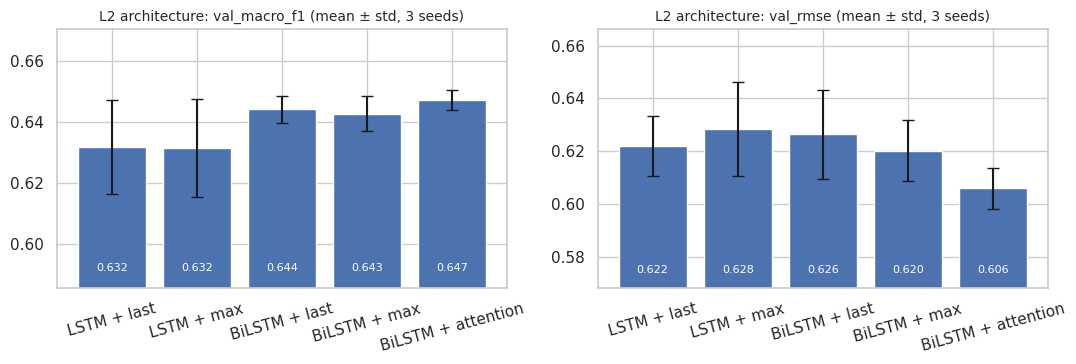

Winner leads the runner-up by 0.0030; seed std 0.0045 -> within seed noise
BEST (mean val macro-F1 0.6472): {'emb': 'glove', 'freeze': False, 'dim': 100, 'hidden': 128, 'bidirectional': True, 'pooling': 'attention', 'dropout': 0.5, 'lr': 0.001, 'weighted': True}


In [ ]:
l2 = ex.sweep("L2", [dict(bidirectional=False, pooling="last"),
                     dict(bidirectional=False, pooling="max"),
                     dict(bidirectional=True, pooling="last"),
                     dict(bidirectional=True, pooling="max"),
                     dict(bidirectional=True, pooling="attention")])
l2["setting"] = np.where(l2["bidirectional"], "BiLSTM", "LSTM") + " + " + l2["pooling"]
plot_sweep(l2, "setting", "L2 architecture", FIG + "l2_bilstm_architecture.png")
ex.update(l2, ["bidirectional", "pooling"])

*Interpretation (L2):* reading the tweet in both directions helps a little. The BiLSTM configs score 0.643-0.647 against 0.632 for the one-directional LSTM, and their seed std is about three times smaller (0.003-0.006 vs 0.016). The 0.012 gap is smaller than the LSTM's own seed std, so this is suggestive, not conclusive. Pooling makes no measurable difference to macro-F1 (last 0.644, max 0.643, attention 0.647; the winner leads by 0.003, within seed noise). Attention pooling is carried forward because it has the highest mean, the lowest std and the lowest RMSE (0.606 vs 0.620-0.626), and because its weights can be inspected in the error analysis, not because it is clearly better.

## L3: class weighting

In [ ]:
l3 = ex.sweep("L3", [dict(weighted=False), dict(weighted=True)])
ex.update(l3, ["weighted"])

,weighted,val_macro_f1,f1_std,val_rmse,rmse_std,best_epoch,n_params
0,False,0.6551,0.0043,0.5870,0.0110,11.6667,746548
1,True,0.6472,0.0033,0.6059,0.0078,13.0000,746548


Winner leads the runner-up by 0.0079; seed std 0.0043 -> clear difference
BEST (mean val macro-F1 0.6551): {'emb': 'glove', 'freeze': False, 'dim': 100, 'hidden': 128, 'bidirectional': True, 'pooling': 'attention', 'dropout': 0.5, 'lr': 0.001, 'weighted': False}


*Interpretation (L3):* unlike the TF-IDF baseline (B3), the BiLSTM does better without class weights: 0.655 vs 0.647 macro-F1 (the 0.008 gap is larger than the seed std of 0.004) and a lower RMSE (0.587 vs 0.606). We follow the selection metric and carry the unweighted loss forward. The cost appears on the test set: the final model finds only 37.5% of the negative tweets, against 52.6% for the weighted Logistic Regression and 56.6% for the weighted Transformer. So class weighting still decides how many anti-vaccine tweets are found; the validation result suggests that, for the BiLSTM, the extra negative predictions it produces are wrong often enough to lower macro-F1.

## L4: capacity and regularisation

,hidden,dropout,val_macro_f1,f1_std,val_rmse,rmse_std,best_epoch,n_params
0,64,0.3,0.6529,0.0039,0.5993,0.0101,11.3333,595508
1,64,0.5,0.6527,0.0082,0.5923,0.0044,13.6667,595508
2,128,0.3,0.6471,0.0069,0.6144,0.0009,14.0000,746548
3,128,0.5,0.6551,0.0043,0.5870,0.0110,11.6667,746548
4,256,0.3,0.6504,0.0049,0.6025,0.0054,11.6667,1245236
5,256,0.5,0.6563,0.0032,0.5932,0.0160,13.3333,1245236


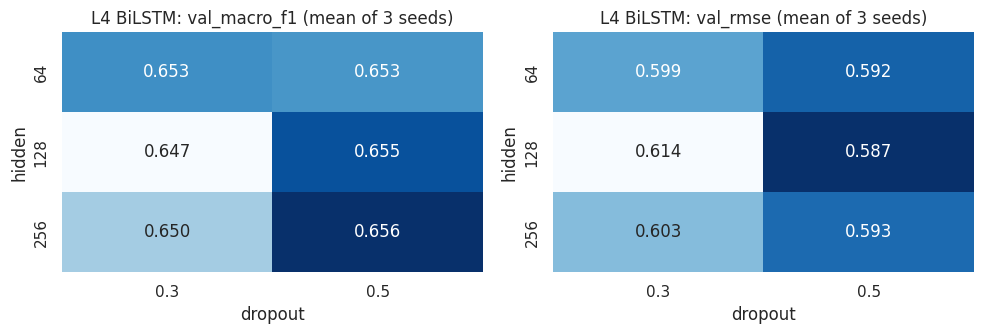

Winner leads the runner-up by 0.0012; seed std 0.0043 -> within seed noise
BEST (mean val macro-F1 0.6563): {'emb': 'glove', 'freeze': False, 'dim': 100, 'hidden': 256, 'bidirectional': True, 'pooling': 'attention', 'dropout': 0.5, 'lr': 0.001, 'weighted': False}


In [ ]:
l4 = ex.sweep("L4", [dict(hidden=h, dropout=d) for h, d in itertools.product([64, 128, 256], [0.3, 0.5])])
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, m in zip(axes, ["val_macro_f1", "val_rmse"]):
    sns.heatmap(l4.pivot(index="hidden", columns="dropout", values=m), annot=True, fmt=".3f",
                cmap="Blues" if m == "val_macro_f1" else "Blues_r", cbar=False, ax=ax)
    ax.set_title(f"L4 BiLSTM: {m} (mean of 3 seeds)")
plt.tight_layout(); plt.savefig(FIG + "l4_bilstm_grid.png", dpi=200); plt.show()
ex.update(l4, ["hidden", "dropout"])

*Interpretation (L4):* capacity and dropout do not matter within this range. All six configs lie between 0.647 and 0.656, and the winner (hidden 256, dropout 0.5) leads the runner-up (hidden 128, dropout 0.5) by 0.001, far inside the seed std (0.004). Dropout 0.5 is at least as good as 0.3 at every size. The runner carries hidden 256 forward because it has the highest mean, but a model with 64 hidden units and half the parameters (0.60M vs 1.25M) would be an equally defensible choice. Making the model bigger or smaller does not change the result, which again points to the data, not the architecture, as the limit.

## L5: GloVe dimension

,dim,val_macro_f1,f1_std,val_rmse,rmse_std,best_epoch,n_params
0,50,0.6317,0.0153,0.5903,0.0079,14.3333,887836
1,100,0.6563,0.0032,0.5932,0.0160,13.3333,1245236
2,200,0.6509,0.0011,0.6041,0.0026,9.6667,1960036


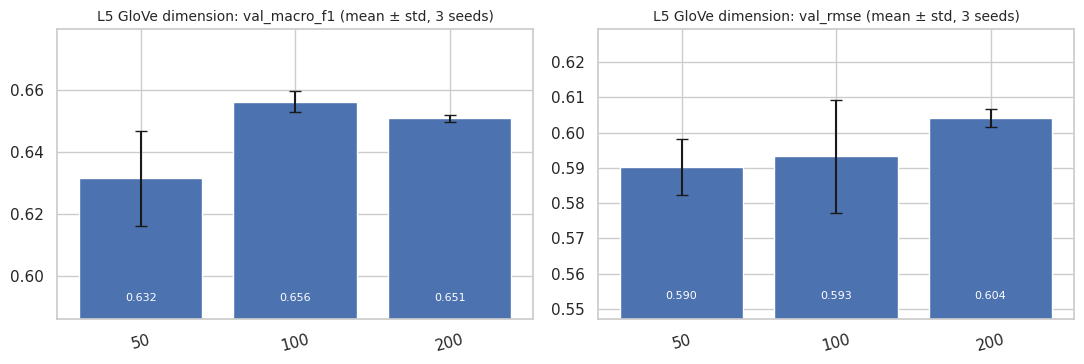

Winner leads the runner-up by 0.0054; seed std 0.0032 -> clear difference
BEST (mean val macro-F1 0.6563): {'emb': 'glove', 'freeze': False, 'dim': 100, 'hidden': 256, 'bidirectional': True, 'pooling': 'attention', 'dropout': 0.5, 'lr': 0.001, 'weighted': False}


In [ ]:
if ex.best["emb"] == "random":
    print("Note: random init won L1, so L5 compares random embedding sizes, not GloVe dimensions.")
l5 = ex.sweep("L5", [dict(dim=50), dict(dim=100), dict(dim=200)])
plot_sweep(l5, "dim", "L5 GloVe dimension", FIG + "l5_bilstm_dim.png")
ex.update(l5, ["dim"])

*Interpretation (L5):* GloVe-100 is the best size: 0.656, against 0.651 for 200 dimensions and 0.632 for 50. The lead over 200d (0.005) is just above the seed std (0.003); the lead over 50d is clear. The 50-dimensional vectors carry too little information and are less stable (std 0.015). The 200-dimensional vectors add 0.7M parameters, overfit sooner (best epoch 9.7 vs 13.3) and have a worse RMSE (0.604 vs 0.593). The final config is therefore unchanged from L4.

## Final model: learning curves and the single test evaluation
The final model is the best config with seed 42 (already trained above, so it is not retrained). Its learning curves show where it starts to overfit; early stopping restored the epoch with the best validation macro-F1.

Final config: {'emb': 'glove', 'freeze': False, 'dim': 100, 'hidden': 256, 'bidirectional': True, 'pooling': 'attention', 'dropout': 0.5, 'lr': 0.001, 'weighted': False} | best epoch 15


,loss,val_loss,acc,val_acc,val_macro_f1,val_rmse
epoch,,,,,,
1,0.8246,0.7474,0.6339,0.6860,0.4837,0.6123
2,0.7083,0.7141,0.7032,0.6874,0.5028,0.6117
3,0.6653,0.6820,0.7219,0.7076,0.5609,0.5911
4,0.6276,0.6724,0.7417,0.7048,0.5687,0.5842
5,0.5894,0.6538,0.7572,0.7188,0.6352,0.5739
6,0.5656,0.6569,0.7707,0.7369,0.6520,0.5742
7,0.5303,0.6862,0.7831,0.7160,0.6162,0.5816
8,0.5078,0.6922,0.7961,0.7271,0.6483,0.5801
9,0.4781,0.7017,0.8074,0.7216,0.6407,0.5881


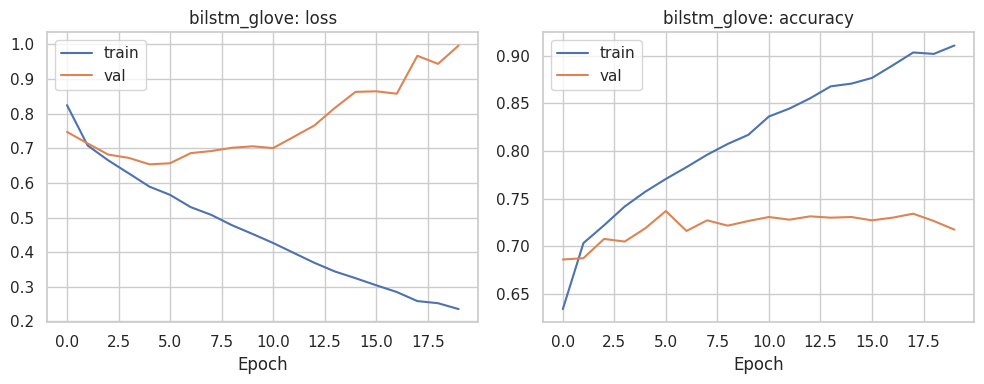

== bilstm_glove | RMSE 0.5977 ==
              precision    recall  f1-score   support

    negative      0.460     0.375     0.413       152
     neutral      0.829     0.769     0.798       693
    positive      0.697     0.789     0.740       589

    accuracy                          0.736      1434
   macro avg      0.662     0.645     0.650      1434
weighted avg      0.736     0.736     0.734      1434



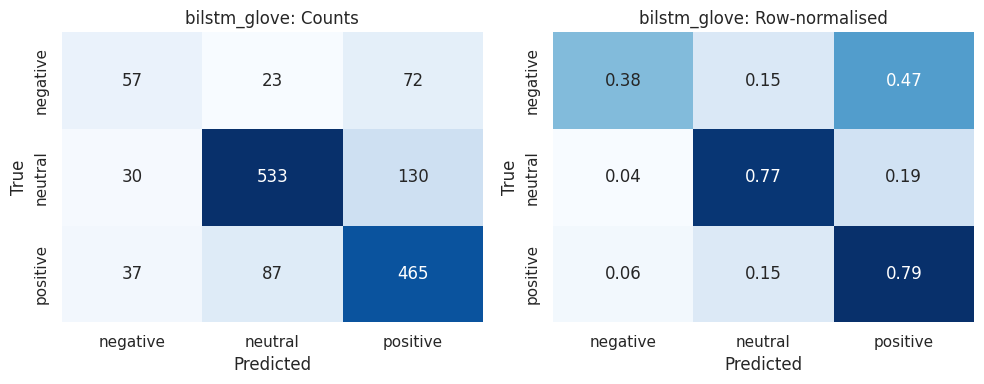

In [ ]:
row, model, hist = ex.run("final", seed=42)
print("Final config:", ex.best, "| best epoch", row["best_epoch"])
display(history_table(hist))
plot_history(hist, MODEL)

_, _, test_dl = make_loaders(datasets)
yp, ys, P = predict(model, test_dl)
evaluate(test["label"], yp, MODEL, y_score=ys)
save_predictions(MODEL, test["tweet_id"], test["safe_text"], test["label"], yp, test["agreement"], ys)
os.makedirs("models", exist_ok=True)
torch.save(model.state_dict(), f"models/{MODEL}.pt")

## Does it handle negation and label noise better than bag-of-words?
Test macro-F1 on slices: tweets with / without negation (the EDA's word-order argument) and with high / low annotator agreement (label noise).

In [ ]:
display(slice_report(["tfidf_logreg", "fasttext", MODEL]).round(3))

model,tfidf_logreg,fasttext,bilstm_glove
slice,,,
agreement < 0.7 (n=583),0.556,0.485,0.517
agreement >= 0.7 (n=851),0.704,0.687,0.755
all (n=1434),0.655,0.605,0.650
no negation (n=1068),0.662,0.619,0.659
with negation (n=366),0.613,0.546,0.604


## What does attention look at in the errors?
Only runs if attention pooling won L2.

In [ ]:
if ex.best["pooling"] == "attention":
    wrong = np.where(yp != test["label"].values)[0][:10]
    names = {-1: "neg", 0: "neu", 1: "pos"}
    for i in wrong:
        ids, _ = datasets[2][i]
        x = torch.tensor([ids], device=DEVICE)
        w = model.attention_weights(x, torch.tensor([len(ids)]))[0].cpu().numpy()
        toks = [vocab.itos[t] for t in ids]
        top = ", ".join(f"{toks[j]}({w[j]:.2f})" for j in w.argsort()[::-1][:5])
        print(f"true {names[test['label'].iloc[i]]} | pred {names[yp[i]]} | {test['safe_text'].iloc[i][:110]}\n   attends to: {top}")
else:
    print("Attention pooling did not win L2; skipped.")

true neg | pred pos | Oh, those evil vaccines will be the death of us all! <url> Measles-infected individual visited Super Bowl Vill
   attends to: vaccines(0.59), evil(0.14), those(0.09), oh(0.04), death(0.03)
true neu | pred pos | Pregnant Nurse In Fear Of Miscarriage Fired For Refusing Flu Vaccine: LANCASTER, Pa. (WJZ)—A woman who lives j
   attends to: refusing(0.30), vaccine(0.18), flu(0.11), woman(0.07), fired(0.06)
true pos | pred neu | SOLS (school of life sciences) <user> seminar: three speakers discussing vaccines.
   attends to: discussing(0.51), vaccines(0.29), three(0.06), <unk>(0.06), school(0.03)
true pos | pred neu | This is what happens when babies aren't vacinated! #vacinate #measles <url>
   attends to: measles(0.32), babies(0.19), vacinate(0.15), aren't(0.13), happens(0.07)
true neg | pred pos | <user> I would be very interested in hearing your opinion after I know you have educated yourself on vaccinati
   attends to: educated(0.21), yourself(0.19), opinion(0.08), 

## Summary
**Summary.** The final BiLSTM (fine-tuned GloVe-100, hidden 256, attention pooling, dropout 0.5, unweighted loss) reaches test macro-F1 0.650, RMSE 0.598 and accuracy 0.736. It ties with TF-IDF + Logistic Regression on macro-F1 (0.655) and beats fastText (0.605). It has the highest accuracy and the best neutral and positive F1 of the models so far, but a lower negative F1 than Logistic Regression (0.413 vs 0.464), because it was trained without class weights (L3).

- **What mattered:** fine-tuned pretrained embeddings (L1, +0.035) and, to a smaller extent, reading in both directions (L2). Pooling, hidden size and dropout were within seed noise. The tokenisation fixes raised GloVe coverage from 85.0% to 93.5% of the vocabulary and from 91.3% to 96.9% of the tokens; the words still missing are mostly hashtags (`vaccineswork`, `cdcwhistleblower`) and emoji names.
- **Overfitting:** validation loss is lowest at epoch 5 (0.654) and then rises to 1.00, while training accuracy climbs to 91% and validation accuracy stays near 73%. Early stopping on macro-F1 kept epoch 15 (F1 0.660, RMSE 0.609) over epoch 6 (F1 0.652, RMSE 0.574): a gain in F1 that is within noise, paid for with over-confident probabilities. This probably explains why the test RMSE is worse than Logistic Regression's (0.584), and it is a limitation of selecting on a noisy metric.
- **Negation:** the BiLSTM is no better than bag-of-n-grams on tweets with negation (0.604 vs 0.613), so the EDA's expectation that a sequential model would handle negation better is not supported at this data size.
- **Label noise:** on tweets with agreement >= 0.7 the BiLSTM is clearly the best model (0.755 vs 0.704); on tweets with agreement < 0.7 it is worse (0.517 vs 0.556). Its advantage is on the tweets that the annotators themselves found clear.
- **Attention on errors:** in the ten misclassified tweets shown above, most of the attention weight is on topic words (`vaccines`, `measles`, `vaccination`) and not on stance cues. Several of the errors are sarcasm ("those evil vaccines will be the death of us all") or news headlines that mention refusing a vaccine.